# Week 5 Lab 1: Linear Regression (Kaggle & Pipelines)

**Goal**: To predict **Medical Charges** based on a patient's **Age** using a single-feature Linear Regression model.

> **Why this lab matters**:
> Before handling 100-feature datasets or complex neural networks, we must understand how a model draws a straight line through data. This establishes the foundation of the mathematical **Adjustment Loop**.

> **Structure**:
> We will use the **6-Phase Professional Workflow** and introduce **Cross Validation** to ensure our model's performance isn't just a lucky guess.

---
## Foreword
In this lab, we use a professional **Kaggle Dataset**: [Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichampel/medical-cost-personal-datasets).

1. **Phase 1: Splitting**
2. **Phase 2: Preprocessing (Standardization)**
3. **Phase 3: Assembly (Pipeline Design)**
4. **Phase 4: Training**
5. **Phase 5: Evaluation (RMSE, MAE & Cross-Validation)**
6. **Phase 6: Optimization**

### 1.1 Import Dependencies & Load Data
**Concept**: We fetch the dataset directly from a reliable GitHub mirror so we always have the same starting point.


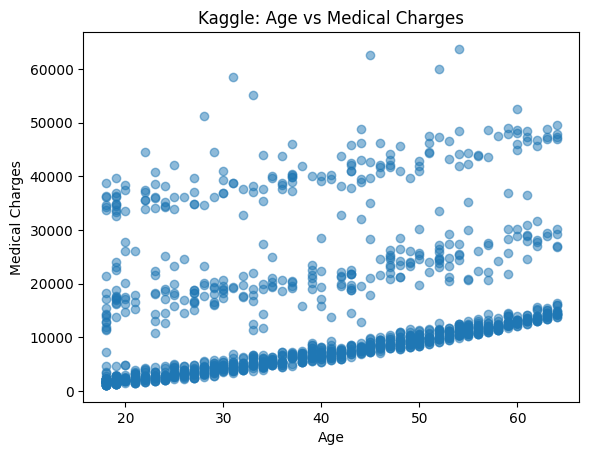

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load Medical Insurance Dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Simple Regression: Age (X) vs Charges (y)
X = df[['age']]
y = df['charges']

plt.scatter(X, y, alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.title("Kaggle: Age vs Medical Charges")
plt.show()

---
### 1.2 Phase 1: Data Splitting
**Concept**: We never train on the final exam. We split the data into 80% training and 20% testing sets.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 1070
Testing set size: 268


---
#### Theory: Scikit-Learn Pipelines
A `Pipeline` links multiple steps together so they act as one single object.

| Pipeline Step | Function | ML Use Case |
| :--- | :--- | :--- |
| `StandardScaler()` | Transformer | Scales numbers to have a mean of 0 and variance of 1. |
| `LinearRegression()` | Estimator | Learns the coefficients (weights) and intercept (bias). |

### 1.3 Phase 2, 3 & 4: Preprocessing, Assembly & Training
**Concept**: We must scale `Age` so it's on a leveled mathematical playing field. But scaling the test set using Test Set averages causes **Data Leakage**.

**Solution**: We use a **Pipeline** to tie the scaler and model together seamlessly. This ensures scaling rules from `X_train` are applied to `X_test`.


In [11]:
workflow = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

workflow.fit(X_train, y_train)

# Extract the model from the pipeline to see what it learned
lr_model = workflow.named_steps['model']
print(f"Learned Scaled Weight (w): {lr_model.coef_[0]:.2f}")
print(f"Learned Scaled Bias (b): {lr_model.intercept_:.2f}")

Learned Scaled Weight (w): 3384.56
Learned Scaled Bias (b): 13346.09


---
### 1.4 Phase 5: Evaluation (Quality Control)
**Concept**: We evaluate how well the model predicts charges for the test group.

**Solution**: We calculate **RMSE** (penalizes large errors heavily) and **MAE** (gives the plain average error).


In [12]:
y_pred = workflow.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"Average Error (MAE): ${mae:,.2f}")
print(f"Penalty Error (RMSE): ${rmse:,.2f}")

Average Error (MAE): $9,173.26
Penalty Error (RMSE): $11,661.22


---
#### Theory: Cross-Validation (K-Fold)
How do we know our 80/20 split didn't just get "lucky" with easy test data?
**Cross-Validation** chops the data into $K$ parts (folds). It trains on $K-1$ parts and tests on the remaining 1 part. It repeats this $K$ times, testing on a different part each time.

### 1.5 Phase 5: Cross-Validation
**Concept**: We want to prove our model's accuracy is stable.
**Solution**: We use `cross_val_score` to run 5-Fold cross validation on our pipeline.


In [13]:
# We pass the WHOLE dataset (X, y) into cross_val_score because it handles the splitting!
# Note: Scikit-learn uses negative MSE by default for scoring, so we convert it back.
scores = cross_val_score(workflow, X, y, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-scores)

print("RMSE Scores across 5 folds:", np.round(rmse_scores, 2))
print(f"\nAverage CV RMSE: ${rmse_scores.mean():,.2f}")
print(f"Standard Deviation: ${rmse_scores.std():,.2f} (How much it varies)")

# Observation: If the Average CV RMSE is close to our Test RMSE from earlier, our model is stable!

RMSE Scores across 5 folds: [11802.59 10709.54 11679.22 11538.24 12032.87]

Average CV RMSE: $11,552.49
Standard Deviation: $451.69 (How much it varies)


> **Observation**: The cross-validation error is closely aligned with our initial test error. This proves our pipeline is robust and hasn't just memorized a "lucky" subset of data.

**Task 1**: Change `cv=5` to `cv=10` in the `cross_val_score` function above. Run the cell again. Does the average error change significantly?

<details>
<summary><strong> Click here for Solution (Try it yourself first!)</strong></summary>

```python
scores_10 = cross_val_score(workflow, X, y, scoring='neg_mean_squared_error', cv=10)
rmse_scores_10 = np.sqrt(-scores_10)
print(f"10-Fold Average CV RMSE: ${rmse_scores_10.mean():,.2f}")
```
The average will change slightly, but it should remain in the same ballpark, further proving stability.
</details>

---
### Summary
Using a real-world dataset, you've seen that as **Age** increases, **Medical Charges** tend to rise linearly. You completely automated this with a **Pipeline** and verified its stability with **Cross-Validation**.

However, notice the wide spread in the scatter plot — there are clearly other factors at play (like smoking or BMI) which we will cover in Lab 2!